# **Quantified Me: Sleep, Stress, and Academic Pressure**

## **A Quantified Self Analysis of Academic Stress, Sleep, and Health Patterns**
### **Isabella Frisbee**
### **CPSC 222, Spring 2026**

## 1. Introduction

### Why is the domain important to you and why are you researching this domain?

I chose this domain because sleep, movement, and stress are all directly connected to my daily life as a college student. During the semester, academic demands can change a lot depending on exams, assignments, and deadlines. I wanted to see whether those stressful academic periods showed up in my personal health data.

This project focuses on the question: **Can my sleep and movement data help explain or predict high-stress academic days?**

### What is the dataset format?

This project uses two CSV files:

1. `apple-health-data.csv`
2. `daily-stress.csv`

The Apple Health dataset was exported from my personal health data and contains daily measurements related to sleep, movement, exercise, and respiratory rate. The daily stress dataset was created manually and contains academic stress information for each day.

### What tables are included in the dataset?

The dataset includes two main tables:

1. **Apple Health Data Table**  
   This table was collected automatically through Apple Health. It contains daily health measurements such as total sleep, exercise time, step count, and respiratory rate.

2. **Daily Stress Table**  
   This table was created manually. It records my daily stress level, whether I had an exam, whether an assignment was due, and my mood.

Both tables contain dates, so they can be joined together using the `Date` field.

### Brief description of the attributes

For the final version of the project, I chose to focus on a smaller set of variables so the analysis would be cleaner and easier to explain.

From Apple Health, I used total sleep, exercise time, step count, and respiratory rate.

From my manually collected stress data, I used stress level, exam day, assignment due, mood, and mood score.

### What is being classified?

The classification task is to predict whether a day was a **high-stress day** or a **low-stress day**. This is a binary classification problem.

### Potential impacts of the results

This project may help show how academic pressure affects daily wellness patterns. If stress is connected to lower sleep, less exercise, fewer steps, or changes in respiratory rate, then this kind of analysis could help students become more aware of how school affects their health.

### Stakeholders interested in the results

The main stakeholders are students, academic advisors, instructors, and campus wellness programs. Students may use this kind of information to better manage their schedules, while advisors and wellness programs could use similar ideas to understand how academic pressure affects student well-being.

## 2. Data Preparation

In this section, I load both CSV files, clean the data, simplify the Apple Health table, and merge the two tables together by date.

The original Apple Health export had more columns than I needed. To make the project more focused, I chose to keep only the variables most directly connected to my research question: total sleep, exercise time, step count, and respiratory rate.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score

import utils

In [2]:
import utils
health_df, stress_df = utils.load_data("apple-health-data.csv", "daily-stress.csv")

print("Apple Health data shape:", health_df.shape)
print("Daily stress data shape:", stress_df.shape)

display(health_df.head())
display(stress_df.head())

Apple Health data shape: (100, 17)
Daily stress data shape: (100, 5)


,Date/Time,Apple Exercise Time (min),Apple Move Time (min),Apple Stand Hour (hr),Flights Climbed (count),Heart Rate [Min] (bpm),Heart Rate [Max] (bpm),Heart Rate [Avg] (bpm),Respiratory Rate (count/min),Sleep Analysis [Total] (hr),Sleep Analysis [Asleep] (hr),Sleep Analysis [In Bed] (hr),Sleep Analysis [Core] (hr),Sleep Analysis [Deep] (hr),Sleep Analysis [REM] (hr),Sleep Analysis [Awake] (hr),Step Count (steps)
0,2026-01-12 00:00:00,79.0,NaN,12,10.0,56.0,142,86.23,NaN,2.130393,2.130393,0.0,0.000000,0.000000,0.000000,0.000000,13401
1,2026-01-13 00:00:00,83.0,NaN,15,7.0,52.0,140,76.75,13.92,7.540045,0.000000,0.0,4.510719,1.181744,1.847582,0.424437,8619
2,2026-01-14 00:00:00,82.0,NaN,15,12.0,47.0,154,79.39,14.11,7.631653,0.000000,0.0,3.986447,1.498050,2.147156,0.282963,10772
3,2026-01-15 00:00:00,62.0,NaN,13,7.0,51.0,146,74.07,14.49,10.175104,0.000000,0.0,4.895320,2.191700,3.088083,0.208067,6443
4,2026-01-16 00:00:00,33.0,NaN,13,13.0,47.0,139,75.71,13.74,7.673381,0.000000,0.0,4.843739,1.007004,1.822637,0.191422,10454


,Date/Time,Stress Level,Exam Day,Assignment Due,Mood
0,1/12/26 0:00,low,no,no,okay
1,1/13/26 0:00,low,no,no,good
2,1/14/26 0:00,low,no,no,good
3,1/15/26 0:00,low,no,yes,good
4,1/16/26 0:00,low,no,no,good


### Inspecting the original data

Before cleaning, I inspected the column names and the first few rows of both datasets. This helped me decide which columns were useful and which columns should be removed from the final analysis.

In [3]:
print("Apple Health columns:")
for col in health_df.columns:
    print(col)

print("\nDaily Stress columns:")
for col in stress_df.columns:
    print(col)

Apple Health columns:
Date/Time
Apple Exercise Time (min)
Apple Move Time (min)
Apple Stand Hour (hr)
Flights Climbed (count)
Heart Rate [Min] (bpm)
Heart Rate [Max] (bpm)
Heart Rate [Avg] (bpm)
Respiratory Rate (count/min)
Sleep Analysis [Total] (hr)
Sleep Analysis [Asleep] (hr)
Sleep Analysis [In Bed] (hr)
Sleep Analysis [Core] (hr)
Sleep Analysis [Deep] (hr)
Sleep Analysis [REM] (hr)
Sleep Analysis [Awake] (hr)
Step Count (steps)

Daily Stress columns:
Date/Time
Stress Level
Exam Day
Assignment Due
Mood


### Cleaning performed

The Apple Health dataset originally contained several extra columns, including specific sleep-stage columns and an Apple Move Time column. For this project, I cleaned more aggressively and kept only:

- `Sleep Analysis [Total] (hr)`
- `Apple Exercise Time (min)`
- `Step Count (steps)`
- `Respiratory Rate (count/min)`

I made this choice because these variables connect clearly to the research question and make the analysis easier to interpret. I also standardized dates in both tables so they could be merged.

For the stress table, I converted categorical values into numeric values:

- `low stress = 0`
- `high stress = 1`
- `no = 0`
- `yes = 1`
- `exhausted = 1`
- `tired = 2`
- `okay = 3`
- `good = 4`

In [4]:
health_clean = utils.clean_health_data(health_df)
stress_clean = utils.clean_stress_data(stress_df)

display(health_clean.head())
display(stress_clean.head())

print("Cleaned health shape:", health_clean.shape)
print("Cleaned stress shape:", stress_clean.shape)

/Users/izzy/Desktop/CPSC222/Quantified Self Project/utils.py:61: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stress_clean["Date/Time"] = pd.to_datetime(stress_clean["Date/Time"], errors="coerce")


,Date,Sleep Analysis [Total] (hr),Apple Exercise Time (min),Step Count (steps),Respiratory Rate (count/min)
0,2026-01-12,2.130393,79.0,13401,NaN
1,2026-01-13,7.540045,83.0,8619,13.92
2,2026-01-14,7.631653,82.0,10772,14.11
3,2026-01-15,10.175104,62.0,6443,14.49
4,2026-01-16,7.673381,33.0,10454,13.74


,Date,Stress Level,Stress Label,Exam Day,Assignment Due,Mood,Mood Score
0,2026-01-12,low,0,0,0,okay,3
1,2026-01-13,low,0,0,0,good,4
2,2026-01-14,low,0,0,0,good,4
3,2026-01-15,low,0,0,1,good,4
4,2026-01-16,low,0,0,0,good,4


Cleaned health shape: (100, 5)
Cleaned stress shape: (100, 7)


### Missing values

Because Apple Health does not always record every measurement every day, there are some missing values. Instead of deleting every row with a missing value, I kept the rows and handled missing values during classification using median imputation. This preserves more of the dataset while still allowing the models to run.

In [5]:
print("Missing values in cleaned health data:")
display(health_clean.isna().sum())

print("Missing values in cleaned stress data:")
display(stress_clean.isna().sum())

Missing values in cleaned health data:


Date                            0
Sleep Analysis [Total] (hr)     3
Apple Exercise Time (min)       2
Step Count (steps)              0
Respiratory Rate (count/min)    3
dtype: int64

Missing values in cleaned stress data:


Date              0
Stress Level      0
Stress Label      0
Exam Day          0
Assignment Due    0
Mood              0
Mood Score        0
dtype: int64

### Merging tables

The two tables were merged using the `Date` column. This creates one combined dataset where each row represents one day and includes both health measurements and stress labels.

In [6]:
merged_df = utils.merge_data(health_clean, stress_clean)

print("Merged data shape:", merged_df.shape)
display(merged_df.head())

Merged data shape: (100, 11)


,Date,Sleep Analysis [Total] (hr),Apple Exercise Time (min),Step Count (steps),Respiratory Rate (count/min),Stress Level,Stress Label,Exam Day,Assignment Due,Mood,Mood Score
0,2026-01-12,2.130393,79.0,13401,NaN,low,0,0,0,okay,3
1,2026-01-13,7.540045,83.0,8619,13.92,low,0,0,0,good,4
2,2026-01-14,7.631653,82.0,10772,14.11,low,0,0,0,good,4
3,2026-01-15,10.175104,62.0,6443,14.49,low,0,0,1,good,4
4,2026-01-16,7.673381,33.0,10454,13.74,low,0,0,0,good,4


### Challenges with data preparation

One challenge was that Apple Health exported more variables than were useful for this specific project. Some columns had mostly zeros or missing values, and including too many columns would make the project harder to interpret. Another challenge was making sure the dates matched correctly between the automatic Apple Health data and the manually recorded stress data.

## 3. Exploratory Data Analysis

### Data aggregation techniques and why

I used several types of aggregation and visualization to understand my dataset. I counted how often high-stress and low-stress days occurred, compared averages across groups, and grouped data by week to look for semester patterns over time.

### Summary statistics used and why

I used means, counts, and standard deviations because they help summarize daily patterns. For example, comparing average sleep on exam days and non-exam days can show whether academic pressure may be connected to sleep changes.

### Visualizations presenting attributes and relationships

To make the project easier to understand, I used several visualization types:

1. Pie chart
2. Bar chart
3. Boxplot
4. Scatterplot
5. Line graph

### Visualization 1: Pie chart of stress level

This pie chart shows the overall distribution of high-stress and low-stress days. This is important because it shows whether the class labels are balanced or imbalanced before classification.

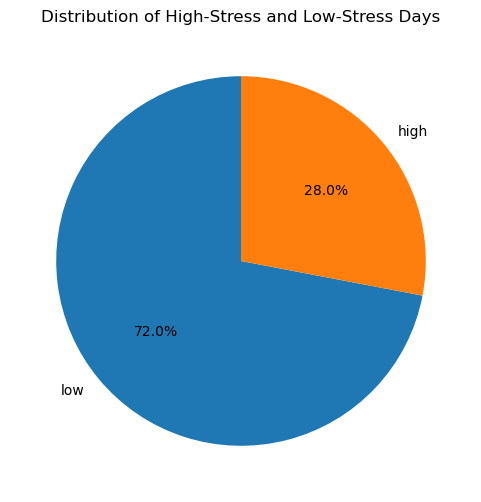

In [7]:
utils.make_stress_pie_chart(merged_df)

### Visualization 2: Average sleep on exam days vs. non-exam days

This bar chart compares average sleep on exam days and non-exam days. I chose this graph because exams are one of the clearest academic stressors in the dataset.

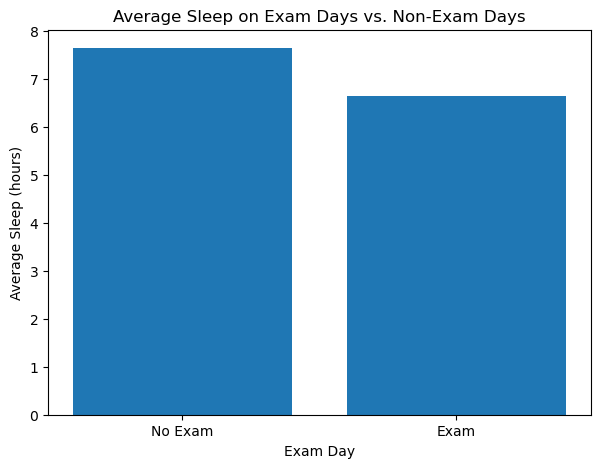

In [8]:
utils.make_avg_sleep_exam_bar(merged_df)

## Statistical Hypothesis Testing

### Hypothesis Test 1: Sleep and stress level

- **Null hypothesis (H₀):** There is no difference in total sleep between high-stress and low-stress days.
- **Alternative hypothesis (H₁):** There is a difference in total sleep between high-stress and low-stress days.

I used a two-sample t-test because I am comparing the means of two groups: high-stress days and low-stress days.

In [9]:
sleep_t_stat, sleep_p_value = utils.run_t_test_by_stress(
    merged_df,
    "Sleep Analysis [Total] (hr)"
)

High-stress mean Sleep Analysis [Total] (hr): 7.328
Low-stress mean Sleep Analysis [Total] (hr): 7.670
t-statistic: -1.180
p-value: 0.2419


### Hypothesis Test 1 Interpretation

If the p-value is less than 0.05, I reject the null hypothesis and conclude that total sleep is significantly different between high-stress and low-stress days. If the p-value is greater than 0.05, I fail to reject the null hypothesis, meaning the dataset does not provide strong enough evidence of a difference.

### Hypothesis Test 2: Respiratory rate and exam days

- **Null hypothesis (H₀):** There is no difference in respiratory rate between exam days and non-exam days.
- **Alternative hypothesis (H₁):** There is a difference in respiratory rate between exam days and non-exam days.

I chose this test because respiratory rate may reflect physical responses to stress, and exam days are a clear academic stress-related category.

In [10]:
resp_t_stat, resp_p_value = utils.run_t_test_by_exam(
    merged_df,
    "Respiratory Rate (count/min)"
)

Exam-day mean Respiratory Rate (count/min): 14.527
Non-exam-day mean Respiratory Rate (count/min): 14.217
t-statistic: 0.769
p-value: 0.4703


### Hypothesis Test 2 Interpretation

If the p-value is less than 0.05, I reject the null hypothesis and conclude that respiratory rate is significantly different on exam days compared to non-exam days. If the p-value is greater than 0.05, I fail to reject the null hypothesis.